# 00 — From research intent to a base dataset: how we chose · **EXPLORE**

**Owner:** Jaime · **Status:** exploration + decision log (sandbox) · **Reading order:** start here, then `01`, `02`

**What this notebook is.** The record of *how we picked the data we build on* — starting from what our project
wants to answer, surveying every dataset the course offers, ruling out the ones that can't serve the question,
and comparing the finalists with real code before committing. Nothing here is a straitjacket: if we learn
something new, we revise. But every decision is tied to the evidence that drove it.

**Why this matters more than the answer.** The goal of this project is as much *learning to interrogate a dataset*
as producing a prediction. So this notebook shows the **cognitive path**, step by step, with clean code, readable
tables and a few focused plots — not just the conclusion.

## 1. The starting point — our research intent and hypothesis

Everything downstream is justified by *this*. Our project asks:

> **Does functional-connectivity reconfiguration from low to high working-memory load (0-back → 2-back)
> predict individual working-memory performance on held-out subjects?**

From that single sentence we can already **derive what the data must contain**. Let's make that explicit —
it becomes our selection checklist.

In [1]:
import pandas as pd

# Requirements DERIVED from the hypothesis — not from any dataset yet.
requirements = pd.DataFrame([
    ("Working-memory task fMRI", "we compare 0-back vs 2-back — needs the N-back task", "hard"),
    ("Parcellated time series",  "connectivity between regions needs ROI time series",  "hard"),
    ("A behavioural WM score",   "the prediction TARGET (accuracy / reaction time)",     "hard"),
    ("Many subjects",            "prediction on held-out subjects needs a sample",       "hard"),
    ("Resting-state (optional)", "only if we keep abstract Objective 2 (intrinsic org.)", "soft"),
], columns=["requirement", "why (traces to hypothesis)", "type"])
requirements

                requirement                             why (traces to hypothesis)  type
0  Working-memory task fMRI    we compare 0-back vs 2-back — needs the N-back task  hard
1   Parcellated time series     connectivity between regions needs ROI time series  hard
2    A behavioural WM score       the prediction TARGET (accuracy / reaction time)  hard
3             Many subjects         prediction on held-out subjects needs a sample  hard
4  Resting-state (optional)  only if we keep abstract Objective 2 (intrinsic org.)  soft

Four **hard** requirements (the study is impossible without them) and one **soft** one (nice to have, tied to a
still-open objective). This checklist is the ruler we measure every candidate against.

## 2. The landscape — what datasets does the course actually offer?

NMA ships a set of fMRI loaders. Before choosing, we look at *all* of them — you can't rule things out you never
listed. We read each loader's own description straight from the official notebooks (reproducible, no download).

In [2]:
from pathlib import Path
import os, json

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "sandbox").exists() else (cwd.parents[1] if cwd.name == "jaime" else cwd)
# locate the official NMA fMRI folder by walking up
OFFICIAL = None
for base in [ROOT, *ROOT.parents]:
    cand = base / "official" / "course-content" / "nma_course_content" / "projects" / "fMRI"
    if cand.exists():
        OFFICIAL = cand; break

# One-line description of each loader (first substantive markdown line)
import re
def first_desc(nb_path):
    nb = json.loads(Path(nb_path).read_text())
    for c in nb["cells"]:
        if c["cell_type"] == "markdown":
            t = re.sub(r"<[^>]+>|\[.*?\]\(.*?\)|https?://\S+|[#&].*?;", " ", "".join(c["source"]))
            t = re.sub(r"\s+", " ", t).strip()
            if len(t) > 60:
                return t
    return ""

loaders = sorted(p.name for p in OFFICIAL.glob("load_*.ipynb"))
landscape = pd.DataFrame({"loader": [l.replace("load_","").replace(".ipynb","") for l in loaders],
                          "description": [first_desc(OFFICIAL/l)[:110] for l in loaders]})
landscape

                            loader                                                                                                     description
0                 algonauts_videos  #Terms of Use By using this colab to download the brain dataset (i.e., data including fMRI, images, labels), y
1  bonner_navigational_affordances  ## Summary Here we will load data from Bonner and Epstein, 2017 [1]. The data consist of fMRI responses to ind
2                   cichy_fMRI_MEG  ## Summary Here we will load data from Cichy et al. 2014 [1]. The data consist of fMRI responses from early vi
3                        fslcourse  # Load the FSL course task dataset We provide data from 2 Tasks. Please watch the data loading video for more 
4                              hcp  # Human Connectome Project (HCP) Dataset loader The HCP dataset comprises resting-state and task-based fMRI fr
5                       hcp_retino  # HCP Retinotopy Data Loader The HCP 7T retinotopyy dataset comprises fMRI retinot

## 3. Ruling out — which datasets *cannot* serve our question, and why

We go down the list against the checklist from §1. Most NMA fMRI datasets are built for **vision / stimulus-encoding**
studies (responses to images or videos), not working memory. Those fail our first hard requirement immediately.

In [3]:
verdicts = pd.DataFrame([
    ("algonauts_videos", "reject", "brain responses to video clips — no WM task, no behaviour target"),
    ("bonner_navigational_affordances", "reject", "scene images + navigation ratings — not WM"),
    ("cichy_fMRI_MEG", "reject", "visual cortex RDMs to images — the old default; dropped at the HCP pivot"),
    ("fslcourse", "reject", "fluency/finger-tapping tasks — not WM, few subjects"),
    ("hcp_retino", "reject", "retinotopy (visual field mapping) — averaged over subjects, no WM"),
    ("kay_images", "reject", "responses to natural images — encoding study, not WM"),
    ("hcp_task", "candidate", "HCP task fMRI incl. WM, 360 ROIs — but NO behaviour target shipped"),
    ("hcp_task_with_behaviour", "FINALIST", "HCP WM task + per-condition behaviour (Stats.txt) — 100 subjects"),
    ("hcp", "FINALIST", "HCP rest + task + behaviour covariates — 339 subjects"),
], columns=["loader", "verdict", "reason (against the §1 checklist)"])
verdicts

                            loader    verdict                                         reason (against the §1 checklist)
0                 algonauts_videos     reject          brain responses to video clips — no WM task, no behaviour target
1  bonner_navigational_affordances     reject                                scene images + navigation ratings — not WM
2                   cichy_fMRI_MEG     reject  visual cortex RDMs to images — the old default; dropped at the HCP pivot
3                        fslcourse     reject                       fluency/finger-tapping tasks — not WM, few subjects
4                       hcp_retino     reject         retinotopy (visual field mapping) — averaged over subjects, no WM
5                       kay_images     reject                      responses to natural images — encoding study, not WM
6                         hcp_task  candidate        HCP task fMRI incl. WM, 360 ROIs — but NO behaviour target shipped
7          hcp_task_with_behaviour   FIN

Six rejects, then three HCP loaders survive. `hcp_task` (no behaviour shipped) is dominated by
`hcp_task_with_behaviour` (same data **plus** the target), so the real contest is between the **two finalists**:

- **`hcp_task_with_behaviour`** — 100 subjects, task-only, rich per-condition behaviour.
- **`hcp`** — 339 subjects, adds **resting-state**, behaviour in a consolidated CSV.

These are the only two worth loading and comparing hands-on.

## 4. Comparing the finalists — with real data, not brochures

We now load **both** and measure the things our checklist cares about. Both are downloaded locally under `data/`
(gitignored). Let's confirm what each physically contains.

In [4]:
import numpy as np
DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))

def acquisitions(hcp_dir, sub):
    d = hcp_dir / "subjects" / sub
    return sorted(p.name for p in d.iterdir() if p.is_dir()) if d.exists() else []

# Finalist A: 100-subject task+behaviour  (subjects/<ID>/<TASK>/...)
A_dir = DATA / "hcp_task"
A_subs = sorted(p.name for p in (A_dir/"subjects").iterdir() if p.is_dir())
A_exps = acquisitions(A_dir, A_subs[0])

# Finalist B: 339-subject rest+task  (rest in hcp_rest/, task in hcp_task_339/, behaviour in hcp/)
B_rest = DATA / "hcp_rest"
B_subs = sorted(p.name for p in (B_rest/"subjects").iterdir() if p.is_dir())
has_rest_B = (B_rest/"subjects"/B_subs[0]/"timeseries").exists()

print("Finalist A (hcp_task_with_behaviour):", len(A_subs), "subjects · experiments:", A_exps[:4], "...")
print("Finalist B (hcp, 339):", len(B_subs), "subjects · resting-state present:", has_rest_B)

Finalist A (hcp_task_with_behaviour): 100 subjects · experiments: ['EMOTION', 'GAMBLING', 'LANGUAGE', 'MOTOR'] ...
Finalist B (hcp, 339): 339 subjects · resting-state present: True


### 4.1 The prediction target — is it there, and does it discriminate subjects?

Our target is 2-back accuracy (`acc_2bk`). A good target has **spread across subjects** (something to predict) and
**no missing values**. We compute it for both finalists and compare the distributions.

In [5]:
# Finalist A target: parsed from per-subject Stats.txt (via our ingestion module)
import sys; sys.path.insert(0, str(ROOT/"sandbox"/"jaime"))
import ingestion as ing
behA = ing.behaviour_table(A_dir, A_subs)

# Finalist B target: from the consolidated behaviour CSV
wm = pd.read_csv(DATA/"hcp"/"behavior"/"wm.csv")
wm["load"] = wm["ConditionName"].str.extract(r"(\dBK)")
accB = wm.groupby(["Subject","load"])["ACC"].mean().unstack()
behB_acc2 = accB["2BK"].dropna()

summary = pd.DataFrame({
    "Finalist A (100, Stats.txt)": [len(behA), behA.acc_2bk.isna().sum(),
                                    behA.acc_2bk.mean(), behA.acc_2bk.min(), behA.acc_2bk.max()],
    "Finalist B (339, wm.csv)":    [len(behB_acc2), 0,
                                    behB_acc2.mean(), behB_acc2.min(), behB_acc2.max()],
}, index=["n subjects","missing acc_2bk","mean","min","max"]).round(3)
summary

                 Finalist A (100, Stats.txt)  Finalist B (339, wm.csv)
n subjects                           100.000                   336.000
missing acc_2bk                        0.000                     0.000
mean                                   0.839                     0.849
min                                    0.538                     0.406
max                                    0.988                     1.000

**Both** targets are usable and comparable (mean ≈ 0.84, wide spread). The 339-subject CSV carries the *same*
per-condition ACC/RT information as our per-subject `Stats.txt` — it is **not** a coarser target, correcting an
earlier assumption. Let's see the distributions side by side.

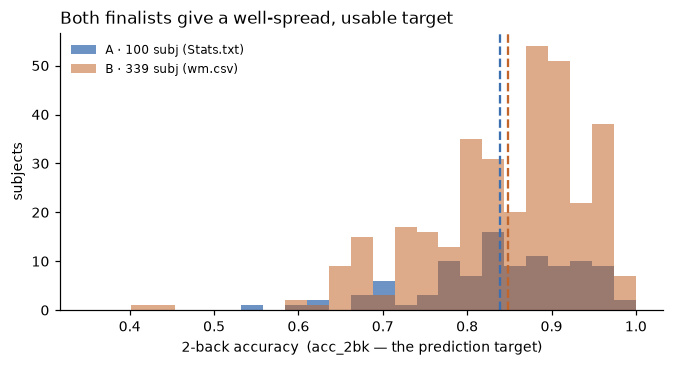

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110, "font.size":9, "axes.spines.top":False, "axes.spines.right":False})

C_A, C_B = "#3b6fb0", "#c1652a"   # two hues, threaded through the notebook
fig, ax = plt.subplots(figsize=(6.2, 3.4))
bins = np.linspace(0.35, 1.0, 26)
ax.hist(behA.acc_2bk, bins=bins, color=C_A, alpha=0.75, label=f"A · 100 subj (Stats.txt)")
ax.hist(behB_acc2,   bins=bins, color=C_B, alpha=0.55, label=f"B · 339 subj (wm.csv)")
ax.axvline(behA.acc_2bk.mean(), color=C_A, lw=1.5, ls="--")
ax.axvline(behB_acc2.mean(),    color=C_B, lw=1.5, ls="--")
ax.set_xlabel("2-back accuracy  (acc_2bk — the prediction target)")
ax.set_ylabel("subjects")
ax.set_title("Both finalists give a well-spread, usable target", loc="left")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("fig_target_distributions.png", dpi=130)
plt.show()

### 4.2 What Finalist B unlocks — real resting-state connectivity

Finalist B adds resting-state (4 runs × 1200 frames). That is a lot of clean data for a stable functional-connectivity
matrix — exactly what abstract **Objective 2** (intrinsic organization) would need. Let's build one sample rest FC
matrix to see it is real and sensible.

rest run: (360, 1200) | mean |r| off-diagonal: 0.469


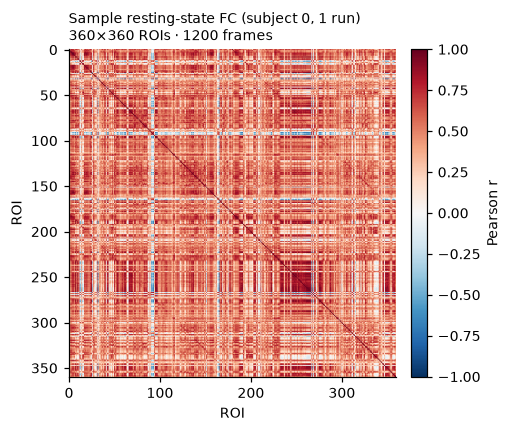

In [7]:
import glob
ts_files = sorted(glob.glob(str(B_rest/"subjects"/B_subs[0]/"timeseries"/"bold*.npy")))
ts = np.load(ts_files[0])
ts = ts - ts.mean(axis=1, keepdims=True)
fc_rest = np.corrcoef(ts)

fig, ax = plt.subplots(figsize=(4.6, 4.0))
im = ax.imshow(fc_rest, cmap="RdBu_r", vmin=-1, vmax=1)   # diverging, centered at 0 (semantic zero)
ax.set_title(f"Sample resting-state FC (subject {B_subs[0]}, 1 run)\n360×360 ROIs · {ts.shape[1]} frames", loc="left", fontsize=9)
ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("Pearson r")
fig.tight_layout()
fig.savefig("fig_rest_fc_sample.png", dpi=130)
plt.show()
print("rest run:", ts.shape, "| mean |r| off-diagonal:", round(np.abs(fc_rest[np.triu_indices(360,1)]).mean(),3))

The block structure (warm on-diagonal blocks = within-network coupling) is the expected signature of real
resting-state FC. So Objective 2 is genuinely reachable **with Finalist B** — at a cost we quantify next.

### 4.3 Head-to-head — the trade-off table

Everything measured above, in one place. This is the actual decision surface.

In [8]:
compare = pd.DataFrame({
    "Finalist A — hcp_task_with_behaviour": [
        "100", "task only (7 tasks incl. WM)", "NO",
        "Stats.txt · per condition, per subject", "already ingested (steps 1-2 done)",
        "richer per-subject files; fewer subjects"],
    "Finalist B — hcp (339)": [
        "339", "task + rest (4 rest runs)", "YES",
        "wm.csv · per condition, consolidated", "would re-ingest on new subject IDs",
        "3.4× more subjects; unlocks Objective 2"],
}, index=["subjects","acquisitions","resting-state","WM behaviour","ingestion status","note"])
compare

                      Finalist A — hcp_task_with_behaviour                   Finalist B — hcp (339)
subjects                                               100                                      339
acquisitions                  task only (7 tasks incl. WM)                task + rest (4 rest runs)
resting-state                                           NO                                      YES
WM behaviour        Stats.txt · per condition, per subject     wm.csv · per condition, consolidated
ingestion status         already ingested (steps 1-2 done)       would re-ingest on new subject IDs
note              richer per-subject files; fewer subjects  3.4× more subjects; unlocks Objective 2

## 5. The decision (team-level, for Monday W2D1)

Not one person's call. Three defensible paths, each costed against the evidence above:

| Option | What it means | Pros | Cons |
|---|---|---|---|
| **A. Stay on Finalist A (100 subj)** | Objectives 1+3 only (task reconfiguration → performance) | Ingestion done; per-subject `Stats.txt`; clean & falsifiable | 100 subjects; no resting-state; drops Obj. 2 |
| **B. Switch to Finalist B (339 subj)** | Enables all 3 objectives incl. real rest FC | 3.4× subjects (better held-out prediction); resting-state; comparable target | Re-ingest on new IDs; more work before Fri Jul 17 |
| **C. Stay on A, reframe Obj. 2 as caveat** | Keep A, discuss intrinsic org. as a limitation | No rework; honest about scope | Obj. 2 stays unaddressed empirically |

**My reading of the evidence:** the earlier worry that switching meant a *coarser* target was **wrong** — `wm.csv`
carries the same per-condition ACC/RT. So Finalist B (Option B) is more attractive than first thought: it gives
**more subjects** *and* **resting-state** at a comparable target quality, for the price of re-running ingestion
(which is scripted and cheap). If the team prioritises a strong held-out prediction and the full 3-objective story,
**B** is defensible. If we optimise for time-to-abstract, **A** or **C**.

This is exactly the kind of trade-off the Monday session should settle — the notebook gives everyone the numbers to
decide, rather than an opinion.

## 6. The method, reusable — how to choose a dataset from scratch

The transferable procedure, for any future dataset question:

1. **Write the hypothesis, then derive the data requirements from it** (§1) — not the other way around.
2. **List the whole landscape** (§2) — you can't reject what you never enumerated.
3. **Rule out against the requirements** (§3) — most candidates fail one hard requirement instantly.
4. **Load the finalists and measure** (§4) — brochures lie; shapes and distributions don't.
5. **Cost every option** (§5) — a capability that exists elsewhere still carries a switching cost; make it explicit.

The point isn't the dataset we end with — it's that we can *justify* it, and re-run the reasoning when we learn more.